<a href="https://colab.research.google.com/github/aljaziya/project1/blob/main/xray_nonxray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#My dataset is available in googledrive; so I am accessing my drive from colab
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
#Once this is executed, you will see your drive appearing on the left hand side

Mounted at /content/drive


In [2]:
# Define paths to the dataset
train_dir = '/content/drive/MyDrive/Colab Notebooks/archive (2)/Xray_Classifier/Xray_Classifier/train'  # Update with your actual path
test_dir = '/content/drive/MyDrive/Colab Notebooks/archive (2)/Xray_Classifier/Xray_Classifier/test'    # Update with your actual path

In [3]:
import os
print(len(os.listdir('/content/drive/MyDrive/Colab Notebooks/archive (2)/Xray_Classifier/Xray_Classifier/train/xray')))
print(len(os.listdir('/content/drive/MyDrive/Colab Notebooks/archive (2)/Xray_Classifier/Xray_Classifier/train/non_xray')))
print(len(os.listdir('/content/drive/MyDrive/Colab Notebooks/archive (2)/Xray_Classifier/Xray_Classifier/test/xray')))
print(len(os.listdir('/content/drive/MyDrive/Colab Notebooks/archive (2)/Xray_Classifier/Xray_Classifier/test/non_xray')))

565
621
565
551


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create ImageDataGenerator for training set
train_datagen = ImageDataGenerator(
    rescale=1./255, #normalisation / feature scaling
    validation_split=0.2  # Split 20% of the images for validation
)

# Load and prepare training data
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',  # 'binary' for binary classification (cats vs. dogs)
    subset='training'  # Specify 'training' for the training set
)

# Create ImageDataGenerator for validation set
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Note: Using the same validation split as in the training set
)

# Load and prepare validation data
validation_data = validation_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    subset='validation'  # Specify 'validation' for the validation set
)

Found 949 images belonging to 2 classes.
Found 236 images belonging to 2 classes.


In [5]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,UpSampling2D, Dropout

In [6]:
# create CNN model - custom-made

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten()) #converting 2D to 1 D

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))  #output layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy']) #binary_crossentropy - binary classification

In [8]:
history = model.fit(train_data, epochs=20, validation_data=validation_data)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 315s 10s/step - accuracy: 0.8714 - loss: 0.2842 - val_accuracy: 0.9237 - val_loss: 0.1748
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 253ms/step - accuracy: 0.9968 - loss: 0.0110 - val_accuracy: 0.9619 - val_loss: 0.1636
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 242ms/step - accuracy: 0.9905 - loss: 0.0453 - val_accuracy: 0.9619 - val_loss: 0.0691
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 250ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 0.9873 - val_loss: 0.0654
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 244ms/step - accuracy: 1.0000 - loss: 4.7414e-04 - val_accuracy: 0.9703 - val_loss: 0.2280
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 249ms/step - accuracy: 1.0000 - loss: 5.6225e-05 - val_accuracy: 0.9873 - val_loss: 0.0941
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 268ms/step - accuracy: 1.0000 - loss: 1.1782e-05 - val_accuracy: 0.9873 - val_loss: 0.1030
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 230ms/step - accuracy: 1.0000 - loss: 1.0217e-05 - 

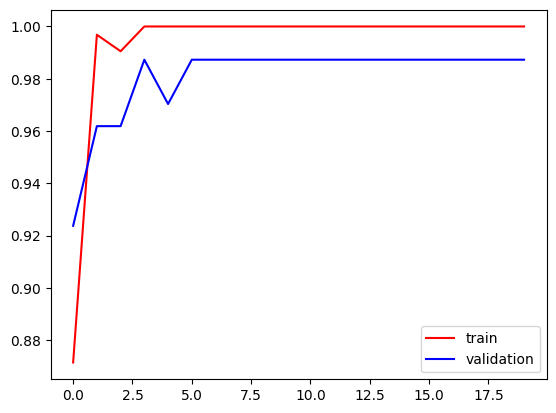

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

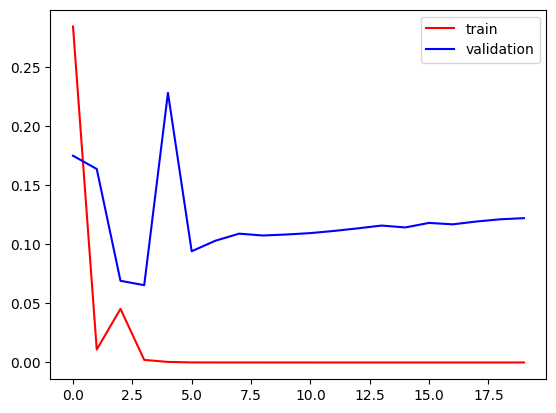

In [10]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [11]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary'
)

Found 1115 images belonging to 2 classes.


In [12]:
#predict the test data
predictions = model.predict(test_data)


35/35 ━━━━━━━━━━━━━━━━━━━━ 260s 8s/step


In [13]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[262 289]
 [286 278]]
Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.48      0.48       551
           1       0.49      0.49      0.49       564

    accuracy                           0.48      1115
   macro avg       0.48      0.48      0.48      1115
weighted avg       0.48      0.48      0.48      1115



In [14]:
# create CNN model

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dropout(0.1))  # added to reduce overfitting
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))  # added to reduce overfitting
model.add(Dense(1,activation='sigmoid'))  #output layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [16]:
history = model.fit(train_data, epochs=20, validation_data=validation_data)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 426ms/step - accuracy: 0.9673 - loss: 0.5583 - val_accuracy: 0.4746 - val_loss: 25.9829
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 241ms/step - accuracy: 0.9758 - loss: 1.0942 - val_accuracy: 0.5466 - val_loss: 12.1073
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 265ms/step - accuracy: 0.9842 - loss: 0.5505 - val_accuracy: 0.5297 - val_loss: 12.0708
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 241ms/step - accuracy: 0.9979 - loss: 0.1853 - val_accuracy: 0.6483 - val_loss: 13.0243
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 272ms/step - accuracy: 0.9926 - loss: 0.3474 - val_accuracy: 0.6780 - val_loss: 14.5078
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 234ms/step - accuracy: 0.9916 - loss: 0.4326 - val_accuracy: 0.8263 - val_loss: 8.0461
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 264ms/step - accuracy: 0.9937 - loss: 0.2923 - val_accuracy: 0.8263 - val_loss: 9.2072
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 237ms/step - accuracy: 0.9958 - loss: 0.0468 - val_accur

In [17]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary'
)

Found 1115 images belonging to 2 classes.


In [18]:
predictions = model.predict(test_data)

35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 192ms/step


In [19]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[262 289]
 [293 271]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.47      0.48      0.47       551
           1       0.48      0.48      0.48       564

    accuracy                           0.48      1115
   macro avg       0.48      0.48      0.48      1115
weighted avg       0.48      0.48      0.48      1115



In [20]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten

resnet_model = Sequential()    #ResNet50 is a pre-trained model
pretrained_model = tf.keras.applications.ResNet50(include_top = False, #because i have my own image of a diff dimension
                                                input_shape = (256,256,3),
                                                pooling = 'max', classes = 2,
                                                weights = 'imagenet')
for layer in pretrained_model.layers:
    layer.trainable = False  #all layers in the Resnet50 is not trainable; keep those weights; I am going to add my own i/p and other layers

resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation = 'relu'))
resnet_model.add(Dense(1, activation = 'sigmoid'))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [21]:
from keras.optimizers import Adam
resnet_model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [22]:
history = resnet_model.fit(train_data, epochs=20, validation_data=validation_data)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 38s 789ms/step - accuracy: 0.5406 - loss: 2.7980 - val_accuracy: 0.5551 - val_loss: 1.3935
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 282ms/step - accuracy: 0.6575 - loss: 0.8485 - val_accuracy: 0.6568 - val_loss: 0.5701
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 251ms/step - accuracy: 0.8398 - loss: 0.3658 - val_accuracy: 0.8136 - val_loss: 0.4371
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 281ms/step - accuracy: 0.8904 - loss: 0.2959 - val_accuracy: 0.7881 - val_loss: 0.4751
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 280ms/step - accuracy: 0.9305 - loss: 0.2375 - val_accuracy: 0.8390 - val_loss: 0.3359
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 261ms/step - accuracy: 0.9283 - loss: 0.2165 - val_accuracy: 0.8602 - val_loss: 0.3073
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 294ms/step - accuracy: 0.9442 - loss: 0.1873 - val_accuracy: 0.8686 - val_loss: 0.2964
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 251ms/step - accuracy: 0.9241 - loss: 0.2021 - val_accuracy: 0

In [23]:
predictions = resnet_model.predict(test_data)

35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 440ms/step


In [24]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[251 300]
 [252 312]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.50      0.46      0.48       551
           1       0.51      0.55      0.53       564

    accuracy                           0.50      1115
   macro avg       0.50      0.50      0.50      1115
weighted avg       0.50      0.50      0.50      1115

